# Employee Promotion Prediction

This notebook builds a complete machine-learning workflow for predicting whether an employee is likely to be promoted. The target variable is binary:

$$
y_i =
\begin{cases}
1 & \text{employee is promoted} \\
0 & \text{employee is not promoted}
\end{cases}
$$

The project is designed around three priorities:

1. **Predictive reliability**: use cross-validation, imbalance-aware training, and threshold optimization instead of relying on a default classifier threshold.
2. **Leakage control**: split the data before analysis and keep all learned transformations inside the modeling pipeline.
3. **Reproducibility**: package feature engineering, preprocessing, feature selection, resampling, and classification into one reusable pipeline artifact.

The full workflow moves through ten phases:

| Phase | Purpose |
|---|---|
| Phase 1 | Prepare the Python environment and import libraries. |
| Phase 2 | Load the dataset and create a stratified train/test split. |
| Phase 3 | Explore the training data only. |
| Phase 4 | Define feature engineering and preprocessing logic. |
| Phase 5 | Build the modeling pipeline. |
| Phase 6 | Optimize hyperparameters with Optuna. |
| Phase 7 | Select a decision threshold from out-of-fold scores. |
| Phase 8 | Train the final model on the full training set. |
| Phase 9 | Evaluate final generalization on the untouched test set. |
| Phase 10 | Save the trained pipeline and its threshold for reuse. |

## Phase 1: Environment Setup

This phase prepares the execution environment. The notebook uses standard scientific Python libraries plus three specialized packages:

- `kagglehub` downloads the dataset programmatically.
- `imbalanced-learn` provides SMOTE, random undersampling, and the sampler-aware pipeline.
- `optuna` performs Bayesian hyperparameter optimization.

The setup cell checks whether each package can be imported. Missing packages are installed into the active Python environment using the current notebook kernel executable. This keeps the notebook portable across Colab, Jupyter, and local virtual environments.

The technical goal of this phase is simple: make the rest of the notebook deterministic and executable without requiring manual package checks.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'optuna': 'optuna',
    'kagglehub': 'kagglehub',
    'imblearn': 'imbalanced-learn',
}

missing = [pip_name for module_name, pip_name in required_packages.items()
           if importlib.util.find_spec(module_name) is None]

if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

print('Environment ready.')

Environment ready.


In [4]:
import os
import pickle
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
warnings.filterwarnings('ignore', category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/khaled/DataComputation/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Phase 2: Data Loading and Stratified Splitting

This phase downloads the employee-promotion dataset, removes the identifier column, separates features from the target, and creates the train/test split.

The column `employee_id` is removed because it is an identifier, not a behavioral signal. Keeping it could allow the model to memorize arbitrary row identity patterns rather than learning general promotion behavior.

The split is stratified because the target is imbalanced. If the positive class rate is

$$
p = \frac{\sum_i y_i}{n}
$$

then stratification tries to keep approximately the same value of $p$ in both the training and test sets. This matters because a random split without stratification can accidentally make the minority class underrepresented in one side of the split.

The test set is not used for feature engineering, model selection, threshold selection, or hyperparameter tuning. It is reserved for the final generalization check.

In [8]:
path = kagglehub.dataset_download('rohit8527kmr7518/employee-promtion-prediction')
data = pd.read_csv(os.path.join(path, 'employee_promotion_prediction.csv'))

if 'employee_id' in data.columns:
    data = data.drop(columns='employee_id')

X = data.drop(columns='promoted')
y = data['promoted']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Full data shape: {data.shape}')
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print(f'Train target distribution: {y_train.value_counts().to_dict()}')
print(f'Test target distribution: {y_test.value_counts().to_dict()}')

100%|██████████| 23.0M/23.0M [00:27<00:00, 865kB/s] 

100%|██████████| 23.0M/23.0M [00:27<00:00, 865kB/s] 

Extracting files...


100%|██████████| 23.0M/23.0M [00:27<00:00, 865kB/s] 

Extracting files...


100%|██████████| 23.0M/23.0M [00:27<00:00, 865kB/s] 

Extracting files...


Full data shape: (100000, 42)
Train shape: (80000, 41), Test shape: (20000, 41)
Train target distribution: {0: 72000, 1: 8000}
Test target distribution: {0: 18000, 1: 2000}


## Phase 3: Training-Only Exploratory Data Analysis

This phase inspects the training data before modeling. The purpose is not to transform data manually; the purpose is to understand the dataset shape, feature types, class balance, missingness, duplicates, and distribution patterns.

Only `X_train` and `y_train` are used here. This is a deliberate leakage-control decision. If the test set influences preprocessing choices, feature selection choices, or threshold choices, then the final test result becomes less trustworthy.

The EDA checks answer practical questions:

- Are there missing values that require imputation?
- Are there duplicated rows that may bias the model?
- Is the target class heavily imbalanced?
- Which numeric features are skewed or bounded?
- Which categorical features are nominal versus ordinal?

The visualizations also motivate later preprocessing choices. Count-like and monetary features often benefit from logarithmic transformation, rate-like features need bounded scaling, and categorical columns need appropriate encoding.

In [4]:
print('=' * 60)
print('TRAINING DATA INFO')
print('=' * 60)
X_train.info()

print('\n' + '=' * 60)
print('TRAINING DATA QUALITY')
print('=' * 60)
print(f'Duplicates: {X_train.duplicated().sum()}')
print(f'Missing values: {X_train.isna().sum().sum()}')
print(f'Promotion rate: {y_train.mean():.2%}')

display(X_train.describe())

TRAINING DATA INFO
<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 12097 to 3877
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         80000 non-null  int64  
 1   gender                      80000 non-null  object 
 2   education_level             80000 non-null  object 
 3   marital_status              80000 non-null  object 
 4   city_tier                   80000 non-null  object 
 5   department                  80000 non-null  object 
 6   employment_type             80000 non-null  object 
 7   years_at_company            80000 non-null  int64  
 8   years_in_current_role       80000 non-null  int64  
 9   years_since_last_promotion  80000 non-null  int64  
 10  team_size                   80000 non-null  int64  
 11  performance_score           80000 non-null  float64
 12  performance_last_year       80000 non-null  float64
 13  performance_tw

,age,years_at_company,years_in_current_role,years_since_last_promotion,team_size,performance_score,performance_last_year,performance_two_years_ago,manager_rating,peer_feedback_score,...,mentoring_sessions,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,40.537625,5.487012,2.745175,2.745437,11.000587,70.114960,68.192107,65.089819,3.303348,3.495774,...,3.000938,101591.929341,7.399319,10410.264509,5660.521175,0.928119,1.994925,69.918684,67.942258,50.011463
std,10.962638,3.487267,2.746049,2.731484,4.910393,14.738883,13.879174,11.796959,0.765426,0.817547,...,1.727563,35969.535120,2.030846,2310.588267,1263.879432,0.046572,1.416324,14.708910,15.650581,19.735321
min,22.000000,0.000000,0.000000,0.000000,3.000000,40.000000,40.000000,40.000000,1.000000,1.000000,...,0.000000,27616.720722,0.000000,2089.305281,788.905587,0.727631,0.000000,20.000000,20.000000,0.000000
25%,31.000000,3.000000,1.000000,1.000000,7.000000,59.484530,58.380832,56.937007,2.771038,2.928814,...,2.000000,83149.984505,6.024050,8813.994639,4813.355855,0.896139,1.000000,59.880695,57.246831,36.509983
50%,41.000000,5.000000,2.000000,2.000000,11.000000,69.975896,68.041855,64.998288,3.303266,3.508686,...,3.000000,96889.950408,7.399314,10410.582882,5664.514820,0.930207,2.000000,70.030690,68.054507,50.043370
75%,50.000000,7.000000,4.000000,4.000000,15.000000,80.648973,77.829319,73.127594,3.836839,4.087898,...,4.000000,112374.638244,8.771633,12005.795866,6507.126983,0.963772,3.000000,80.180703,78.924310,63.415320
max,59.000000,30.000000,28.000000,29.000000,19.000000,100.000000,100.000000,100.000000,5.000000,5.000000,...,13.000000,663817.278916,15.996288,19615.455082,10846.763857,1.000000,11.000000,100.000000,100.000000,100.000000


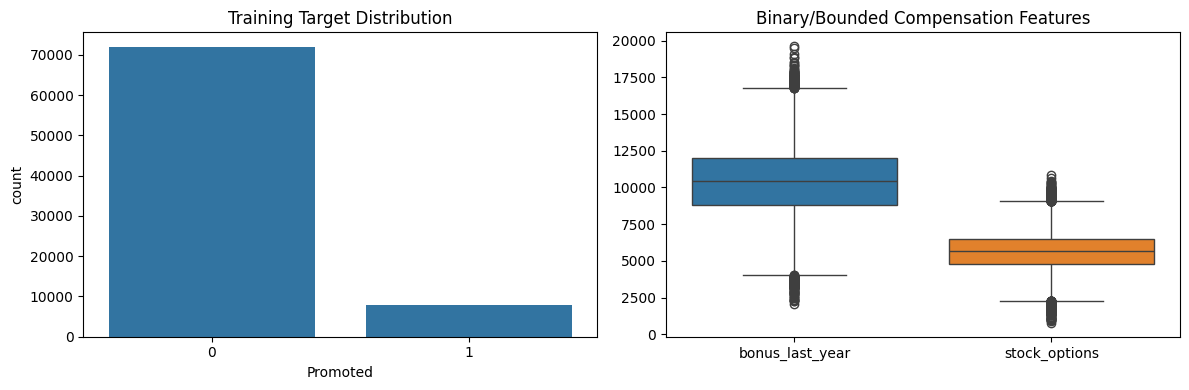

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Training Target Distribution')
axes[0].set_xlabel('Promoted')

sns.boxplot(data=X_train[['bonus_last_year', 'stock_options']], ax=axes[1])
axes[1].set_title('Binary/Bounded Compensation Features')
plt.tight_layout()
plt.show()

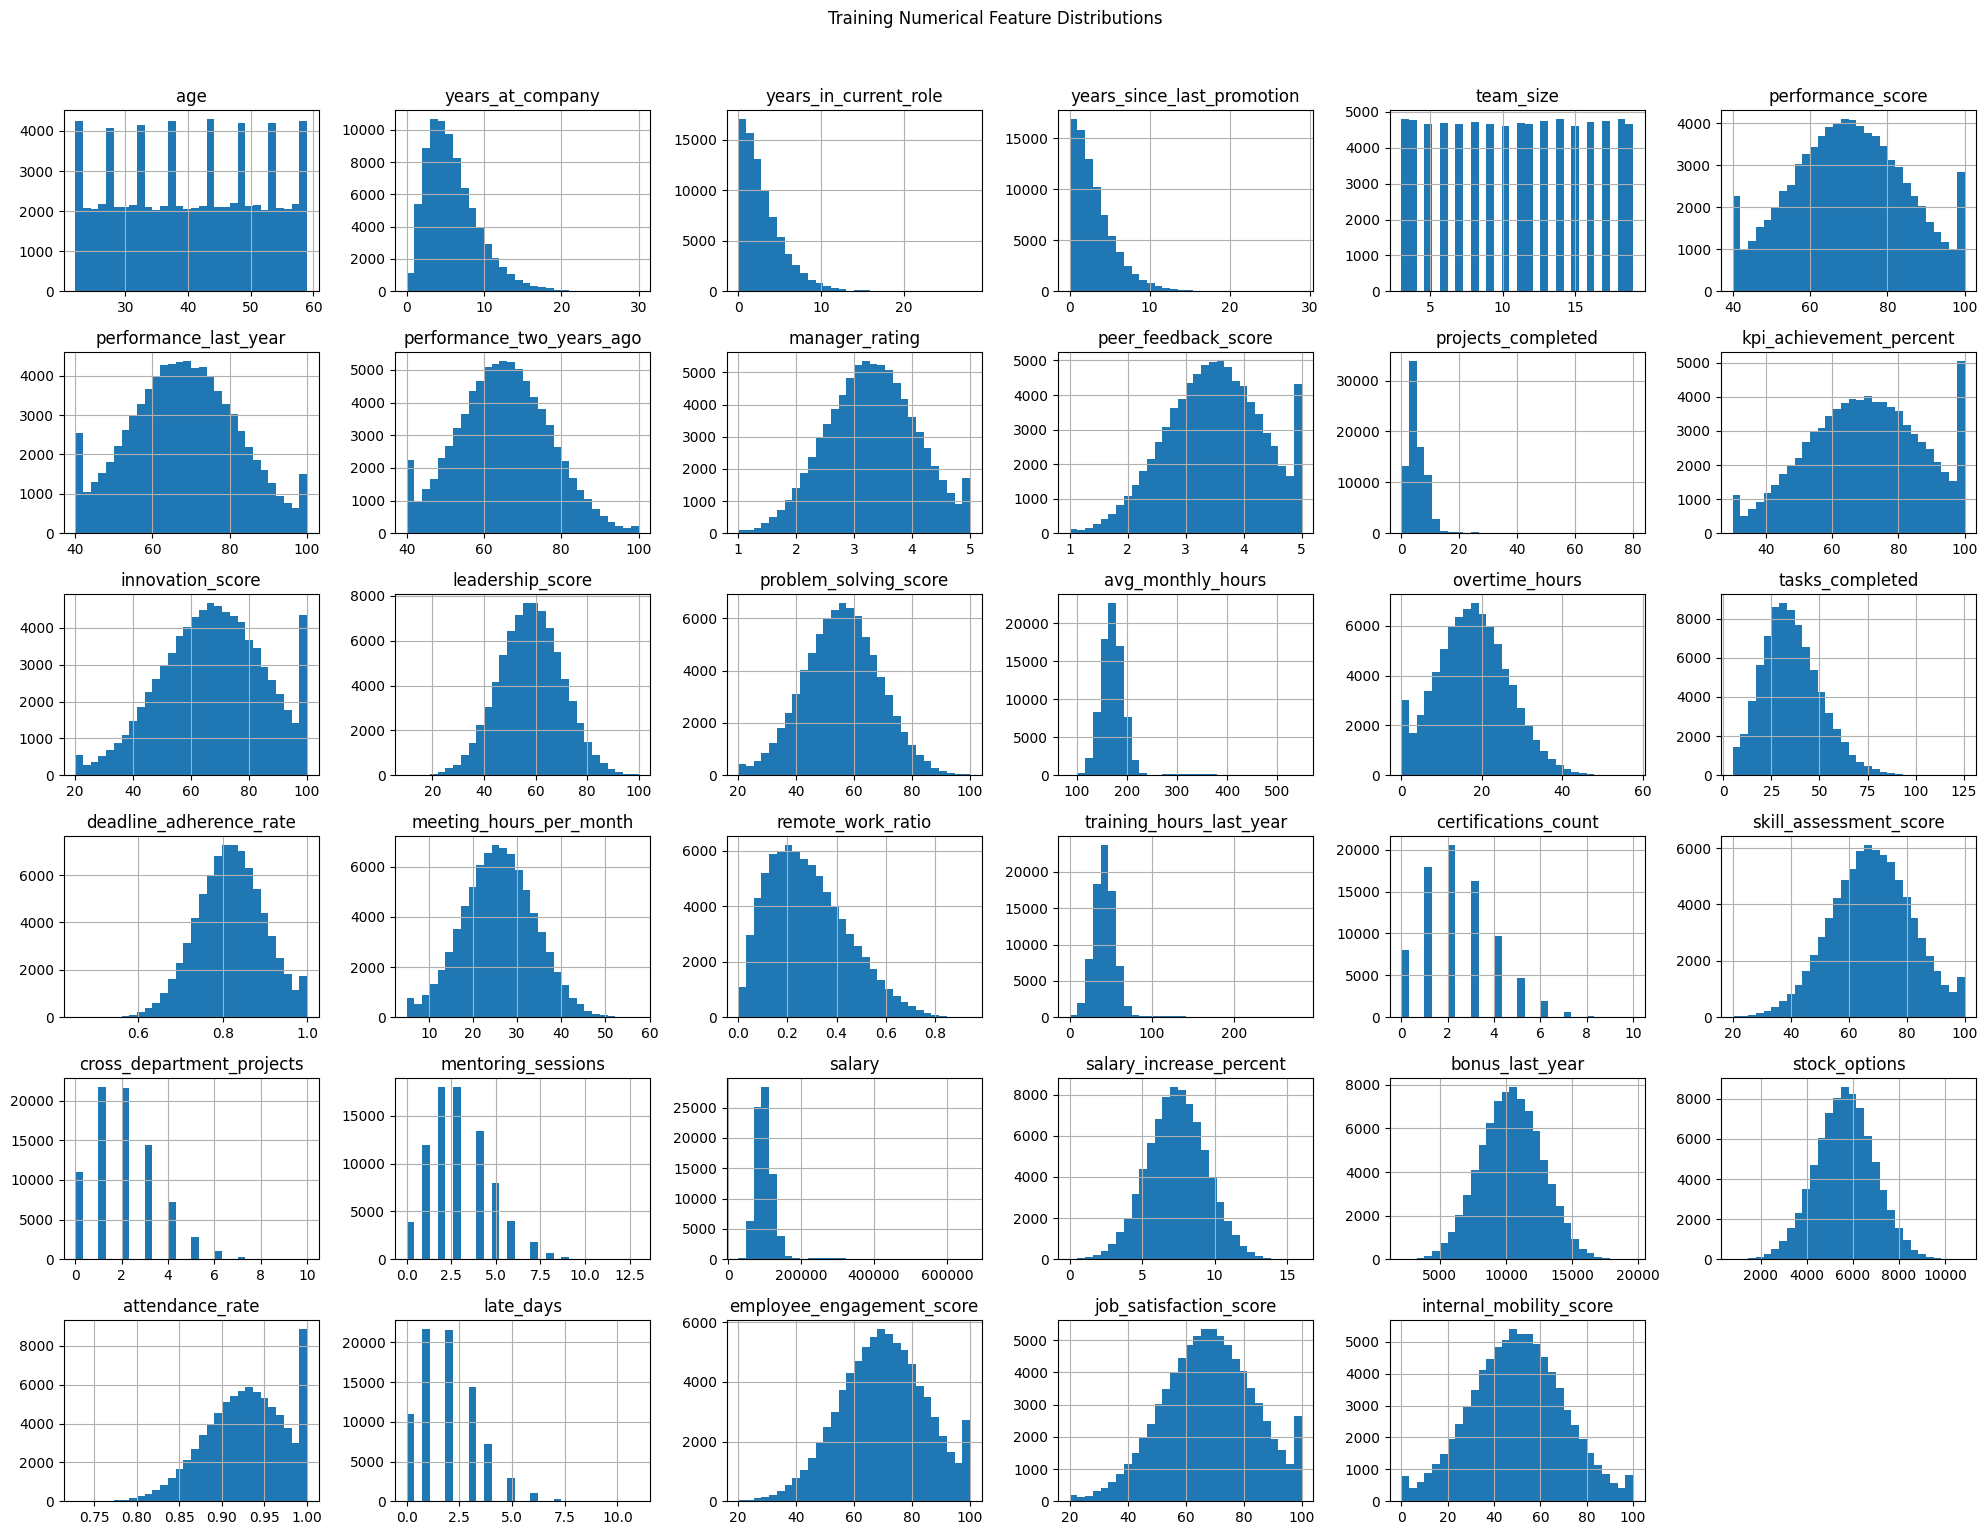

In [6]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[num_cols].hist(figsize=(20, 15), bins=30)
plt.suptitle('Training Numerical Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
if {'education_level', 'city_tier'}.issubset(X_train.columns):
    display(X_train[['education_level', 'city_tier']].value_counts())

education_level  city_tier
Bachelor         Tier1        20735
                 Tier2        18076
                 Tier3        12977
Master           Tier1         9671
                 Tier2         8412
                 Tier3         5999
PhD              Tier1         1691
                 Tier2         1411
                 Tier3         1028
Name: count, dtype: int64

## Phase 4: Feature Engineering and Preprocessing Design

This phase defines how raw columns become model-ready numeric features. The design separates feature engineering from column preprocessing, then combines both inside the pipeline.

### Feature Engineering Logic

Several skewed numeric columns are transformed using:

$$
x' = \log(1 + x)
$$

The `log1p` form is used instead of `log(x)` because many count variables can be zero. The transformation compresses large values while preserving zero safely:

$$
\log(1 + 0) = 0
$$

Ordinal categories are mapped to ordered numeric values because their labels have a natural rank:

$$
\text{Bachelor}=1, \quad \text{Master}=2, \quad \text{PhD}=3
$$

$$
\text{Tier3}=1, \quad \text{Tier2}=2, \quad \text{Tier1}=3
$$

Additional ratio features are added to express domain relationships that may be more predictive than raw columns alone:

$$
\text{promotion\_rate} = \frac{1}{\text{years\_since\_last\_promotion}+1}
$$

$$
\text{performance\_efficiency} = \frac{\text{performance\_score}}{\text{avg\_monthly\_hours}+1}
$$

$$
\text{leadership\_tenure\_ratio} = \frac{\text{leadership\_score}}{\text{years\_at\_company}+1}
$$

$$
\text{skill\_cert\_ratio} = \frac{\text{skill\_assessment\_score}}{\text{certifications\_count}+1}
$$

The `+1` terms prevent division by zero and make the ratios stable for employees with zero tenure-like or count-like values.

### Preprocessing Logic

Different feature families receive different transformations:

| Feature family | Transformer | Reason |
|---|---|---|
| Nominal categories | One-hot encoding | No natural order should be imposed. |
| Continuous numeric features | RobustScaler | Median/IQR scaling is resistant to outliers. |
| Bounded percentages/rates | MinMaxScaler | Keeps bounded values in a comparable range. |
| Binary indicators | Passthrough | Already represented as 0/1 signals. |

Robust scaling uses the median and interquartile range:

$$
z = \frac{x - \text{median}(x)}{Q_3(x) - Q_1(x)}
$$

This is preferable to standard scaling when outliers are present because the mean and standard deviation can be pulled heavily by extreme values.

In [8]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, log_cols=None):
        self.log_cols = log_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        log_cols = self.log_cols or []
        for col in log_cols:
            if col in X.columns:
                X[col] = np.log1p(X[col])

        education_mapping = {'Bachelor': 1, 'Master': 2, 'PhD': 3}
        city_tier_mapping = {'Tier1': 3, 'Tier2': 2, 'Tier3': 1}
        X['education_level'] = X['education_level'].map(education_mapping)
        X['city_tier'] = X['city_tier'].map(city_tier_mapping)

        X['promotion_rate'] = 1 / (X['years_since_last_promotion'] + 1)
        X['performance_efficiency'] = X['performance_score'] / (X['avg_monthly_hours'] + 1)
        X['leadership_tenure_ratio'] = X['leadership_score'] / (X['years_at_company'] + 1)
        X['skill_cert_ratio'] = X['skill_assessment_score'] / (X['certifications_count'] + 1)
        return X

In [9]:
log_cols = [
    'salary', 'years_at_company', 'years_in_current_role',
    'years_since_last_promotion', 'projects_completed',
    'certifications_count', 'mentoring_sessions', 'late_days',
    'cross_department_projects', 'training_hours_last_year',
]

nominal_features = ['gender', 'marital_status', 'department', 'employment_type']
bounded_features = ['attendance_rate', 'kpi_achievement_percent']
binary_features = ['bonus_last_year', 'stock_options']

numeric_features_after_fe = [
    'age', 'education_level', 'city_tier', 'years_at_company',
    'years_in_current_role', 'years_since_last_promotion', 'team_size',
    'performance_score', 'performance_last_year', 'performance_two_years_ago',
    'manager_rating', 'peer_feedback_score', 'projects_completed',
    'innovation_score', 'leadership_score', 'problem_solving_score',
    'avg_monthly_hours', 'overtime_hours', 'tasks_completed',
    'deadline_adherence_rate', 'meeting_hours_per_month', 'remote_work_ratio',
    'training_hours_last_year', 'certifications_count', 'skill_assessment_score',
    'cross_department_projects', 'mentoring_sessions', 'salary',
    'salary_increase_percent', 'late_days', 'employee_engagement_score',
    'job_satisfaction_score', 'internal_mobility_score', 'promotion_rate',
    'performance_efficiency', 'leadership_tenure_ratio', 'skill_cert_ratio',
]

robust_features = [
    col for col in numeric_features_after_fe
    if col not in bounded_features + binary_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_features),
        ('robust', RobustScaler(), robust_features),
        ('minmax', MinMaxScaler(), bounded_features),
        ('binary', 'passthrough', binary_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print(f'Nominal features: {len(nominal_features)}')
print(f'Robust-scaled features: {len(robust_features)}')
print(f'MinMax-scaled features: {len(bounded_features)}')
print(f'Passthrough binary features: {len(binary_features)}')

Nominal features: 4
Robust-scaled features: 37
MinMax-scaled features: 2
Passthrough binary features: 2


## Phase 5: Modeling Pipeline Architecture

This phase creates the complete modeling pipeline. The pipeline is the central engineering object in the notebook: it defines the exact sequence of transformations that every training fold, final training run, and future prediction must follow.

The model family is a linear support-vector classifier. A linear SVM learns a separating hyperplane:

$$
f(x) = w^T x + b
$$

The predicted class is based on the sign of this decision score, while the distance from zero gives a ranking signal that can later be threshold-tuned.

The optimization objective for a soft-margin linear SVM can be written conceptually as:

$$
\min_{w,b} \frac{1}{2}\lVert w \rVert^2 + C \sum_i \xi_i
$$

subject to:

$$
y_i(w^T x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0
$$

The parameter $C$ controls the tradeoff between a wider margin and classification errors. Smaller $C$ regularizes more strongly; larger $C$ tries harder to classify training examples correctly.

### Pipeline Drawing

```mermaid
flowchart TD
    A[Raw training fold] --> B[FeatureEngineer]
    B --> C[ColumnTransformer]
    C --> D[RFE feature selection]
    D --> E[SMOTE minority oversampling]
    E --> F[Random undersampling of majority class]
    F --> G[LinearSVC classifier]
    G --> H[Decision scores]

    A2[Raw validation/test data] --> B2[FeatureEngineer]
    B2 --> C2[ColumnTransformer fitted on training fold]
    C2 --> D2[RFE selected columns]
    D2 --> G2[LinearSVC classifier]
    G2 --> H2[Decision scores]
```

Plain-text view of the same flow:

```text
Training fold:
Raw data
  -> FeatureEngineer
  -> ColumnTransformer
  -> RFE selected feature matrix
  -> SMOTE creates minority examples
  -> RandomUnderSampler reduces majority examples
  -> LinearSVC learns the final hyperplane
  -> decision_function scores

Validation/test/future data:
Raw data
  -> FeatureEngineer
  -> fitted ColumnTransformer
  -> fitted RFE selected columns
  -> fitted LinearSVC
  -> decision_function scores
  -> threshold rule
```


### How Data Moves Through the Pipeline

1. **Raw features enter the pipeline** as a pandas DataFrame.
2. **Feature engineering** adds log-transformed columns, ordinal encodings, and ratio features.
3. **Column preprocessing** converts all model inputs into numeric arrays with appropriate scaling.
4. **RFE** recursively removes weaker features using a linear SVM estimator until the selected feature count is reached.
5. **SMOTE** creates synthetic minority-class examples in the selected feature space.
6. **Random undersampling** reduces the majority class to a controlled ratio.
7. **LinearSVC** fits the final separating hyperplane.

During prediction, the resampling steps are skipped automatically by the `imblearn` pipeline. New data is transformed, reduced to the selected features, and passed directly to the trained classifier.

This architecture prevents data leakage because feature selection, scaling, and resampling are refit separately inside each cross-validation training fold.

In [10]:
def make_pipeline(
    classifier_c=0.01,
    selector_c=0.01,
    class_weight='balanced',
    n_features=20,
    smote_strategy=0.15,
    under_strategy=0.90,
):
    selector_estimator = LinearSVC(
        C=selector_c,
        class_weight='balanced',
        dual=False,
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    classifier = LinearSVC(
        C=classifier_c,
        class_weight=class_weight,
        dual=False,
        max_iter=20000,
        random_state=RANDOM_STATE,
    )

    return ImbPipeline(steps=[
        ('features', FeatureEngineer(log_cols=log_cols)),
        ('preprocess', preprocessor),
        ('feature_selection', RFE(
            estimator=selector_estimator,
            n_features_to_select=n_features,
            step=0.25,
        )),
        ('smote', SMOTE(sampling_strategy=smote_strategy, random_state=RANDOM_STATE, k_neighbors=5)),
        ('under', RandomUnderSampler(sampling_strategy=under_strategy, random_state=RANDOM_STATE)),
        ('classifier', classifier),
    ])

base_pipeline = make_pipeline()
base_pipeline

Pipeline(steps=[('features',
                 FeatureEngineer(log_cols=['salary', 'years_at_company',
                                           'years_in_current_role',
                                           'years_since_last_promotion',
                                           'projects_completed',
                                           'certifications_count',
                                           'mentoring_sessions', 'late_days',
                                           'cross_department_projects',
                                           'training_hours_last_year'])),
                ('preprocess',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='fir...
                 RFE(estimator=LinearSVC(C=0.01, class_weight='balanced',
                                         dual=False, max_iter=20000,
                                         random_state=42),
                     n_features_to_select=20, step=0.25)),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.15)),
                ('under',
                 RandomUnderSampler(random_state=42, sampling_strategy=0.9)),
                ('classifier',
                 LinearSVC(C=0.01, class_weight='balanced', dual=False,
                           max_iter=20000, random_state=42))])

## Phase 6: Bayesian Hyperparameter Optimization with Optuna

This phase tunes the most important modeling choices using Optuna. Instead of manually trying a grid of values, Optuna uses a Bayesian-style search strategy through the Tree-structured Parzen Estimator sampler. It spends more trials near promising regions of the search space while still exploring alternatives.

The objective function trains and validates the full pipeline using stratified cross-validation. For each trial, Optuna proposes values for:

| Hyperparameter | Meaning |
|---|---|
| `classifier_c` | Regularization strength of the final LinearSVC. |
| `selector_c` | Regularization strength of the LinearSVC used inside RFE. |
| `class_weight` | Whether the classifier should internally weight minority errors more heavily. |
| `n_features` | Number of features retained by RFE. |
| `smote_strategy` | Minority/majority ratio after SMOTE. |
| `under_strategy` | Minority/majority ratio after undersampling. |

The validation metric is F1-score:

$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

where:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

F1 is appropriate here because the positive class is much smaller than the negative class. Accuracy alone would be misleading: a model could predict almost everyone as not promoted and still achieve high accuracy.

The objective returns the mean cross-validated F1:

$$
\text{CV F1} = \frac{1}{K}\sum_{k=1}^{K} F_{1,k}
$$

where $K=3$ folds in this notebook.

In [11]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    pipeline = make_pipeline(
        classifier_c=trial.suggest_float('classifier_c', 1e-3, 10.0, log=True),
        selector_c=trial.suggest_float('selector_c', 1e-3, 0.1, log=True),
        class_weight=trial.suggest_categorical('class_weight', ['balanced', None]),
        n_features=trial.suggest_int('n_features', 15, 30, step=5),
        smote_strategy=trial.suggest_float('smote_strategy', 0.12, 0.25),
        under_strategy=trial.suggest_float('under_strategy', 0.60, 0.95),
    )

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        error_score='raise',
    )
    return scores.mean()

In [12]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name='linear_svm_employee_promotion',
)

study.optimize(objective, n_trials=20, show_progress_bar=True)

print('=' * 60)
print('OPTUNA COMPLETE')
print('=' * 60)
print(f'Best CV F1: {study.best_value:.4f}')
print(f'Best parameters: {study.best_params}')

  0%|          | 0/20 [00:00<?, ?it/s]

OPTUNA COMPLETE
Best CV F1: 0.5891
Best parameters: {'classifier_c': 0.8304993906265253, 'selector_c': 0.03797755289584503, 'class_weight': None, 'n_features': 25, 'smote_strategy': 0.204652758370181, 'under_strategy': 0.6063624472790284}


## Phase 7: Decision Threshold Selection

A linear SVM produces decision scores, not calibrated probabilities. The default classification rule is usually:

$$
\hat{y} = \mathbb{1} [f(x) > 0]
$$

For imbalanced classification, the default threshold of zero is not always the best operating point. A higher threshold can increase precision, while a lower threshold can increase recall.

This phase estimates a threshold using out-of-fold training scores. Out-of-fold scoring means each training row receives a decision score from a model that did not train on that row. This makes the threshold selection less optimistic than using scores from a model evaluated on its own training data.

The selected rule becomes:

$$
\hat{y} = \mathbb{1} [f(x) > \tau]
$$

where $\tau$ is the threshold that maximizes F1 on the out-of-fold scores.

In [13]:
best_params = study.best_params
final_pipeline = make_pipeline(
    classifier_c=best_params['classifier_c'],
    selector_c=best_params['selector_c'],
    class_weight=best_params['class_weight'],
    n_features=best_params['n_features'],
    smote_strategy=best_params['smote_strategy'],
    under_strategy=best_params['under_strategy'],
)

oof_scores = cross_val_predict(
    clone(final_pipeline),
    X_train,
    y_train,
    cv=cv,
    method='decision_function',
    n_jobs=-1,
)

precision, recall, thresholds = precision_recall_curve(y_train, oof_scores)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[optimal_idx]

print('=' * 60)
print('OUT-OF-FOLD THRESHOLD SELECTION')
print('=' * 60)
print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'OOF F1 at threshold: {f1_scores[optimal_idx]:.4f}')

OUT-OF-FOLD THRESHOLD SELECTION
Optimal threshold: 0.2803
OOF F1 at threshold: 0.6182


## Phase 8: Final Model Training

After hyperparameter optimization and threshold selection, the final pipeline is trained once on the complete training set.

This training run uses the best Optuna parameters and follows the same pipeline order used during cross-validation:

$$
\text{Feature Engineering} \rightarrow \text{Preprocessing} \rightarrow \text{RFE} \rightarrow \text{SMOTE} \rightarrow \text{Undersampling} \rightarrow \text{LinearSVC}
$$

The reason for fitting on the full training set at this stage is that model selection is already complete. The model can now use all available training information before being evaluated on the untouched test set.

In [ ]:
final_pipeline.fit(X_train, y_train)
print('Final pipeline trained successfully.')

## Phase 9: Final Evaluation

This phase evaluates the final trained pipeline on the test set. The test set has not been used for preprocessing decisions, hyperparameter search, resampling, feature selection, or threshold selection.

The report focuses on class-specific metrics:

- **Precision**: among predicted promotions, how many were correct?
- **Recall**: among actual promotions, how many were found?
- **F1-score**: the harmonic balance between precision and recall.
- **Confusion matrix**: the counts of true negatives, false positives, false negatives, and true positives.

The confusion matrix is interpreted as:

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

For this problem, the promoted class is usually the main class of interest. That makes the promoted-class precision, recall, and F1 more informative than accuracy alone.

The training-set check is included only as an overfitting diagnostic. A large train/test F1 gap suggests that the pipeline may be fitting noise rather than generalizable promotion patterns.

TEST SET REPORT (threshold=0.2803)
              precision    recall  f1-score   support

Not Promoted       0.96      0.94      0.95     18000
    Promoted       0.58      0.68      0.63      2000

    accuracy                           0.92     20000
   macro avg       0.77      0.81      0.79     20000
weighted avg       0.93      0.92      0.92     20000



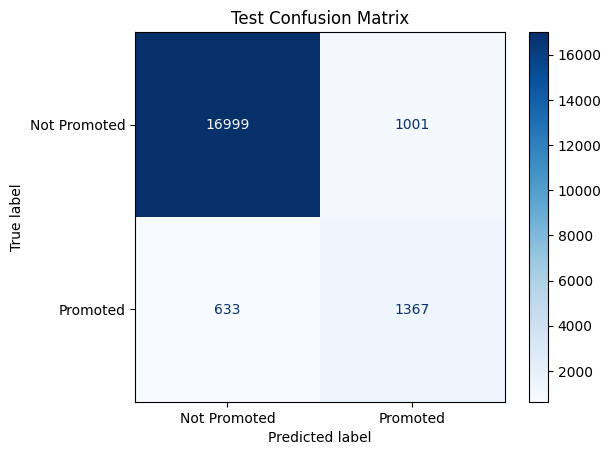

In [15]:
y_test_scores = final_pipeline.decision_function(X_test)
y_test_pred = (y_test_scores > optimal_threshold).astype(int)

print('=' * 60)
print(f'TEST SET REPORT (threshold={optimal_threshold:.4f})')
print('=' * 60)
print(classification_report(y_test, y_test_pred, target_names=['Not Promoted', 'Promoted']))

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Promoted', 'Promoted']).plot(cmap='Blues')
plt.title('Test Confusion Matrix')
plt.show()

In [16]:
y_train_scores = final_pipeline.decision_function(X_train)
y_train_pred = (y_train_scores > optimal_threshold).astype(int)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print('=' * 60)
print('TRAINING SET CHECK')
print('=' * 60)
print(classification_report(y_train, y_train_pred, target_names=['Not Promoted', 'Promoted']))
print(f'Train F1: {train_f1:.4f}')
print(f'Test F1: {test_f1:.4f}')
print(f'Absolute gap: {abs(train_f1 - test_f1):.4f}')

TRAINING SET CHECK
              precision    recall  f1-score   support

Not Promoted       0.96      0.95      0.95     72000
    Promoted       0.58      0.67      0.62      8000

    accuracy                           0.92     80000
   macro avg       0.77      0.81      0.79     80000
weighted avg       0.92      0.92      0.92     80000

Train F1: 0.6200
Test F1: 0.6259
Absolute gap: 0.0059


## Phase 10: Artifact Persistence

This phase saves the trained model package for future use. The artifact contains:

- the fitted pipeline,
- the selected decision threshold,
- the best Optuna parameters,
- the best cross-validation F1 score.

Saving the threshold is essential. The classifier alone does not represent the final prediction rule. The deployed prediction logic is:

$$
\hat{y} = \mathbb{1}[\text{pipeline.decision\_function}(x) > \tau]
$$

where $\tau$ is the threshold selected in Phase 7.

Because preprocessing and feature engineering are inside the fitted pipeline, future raw employee records can be passed through the same transformations used during training.

In [17]:
artifact = {
    'pipeline': final_pipeline,
    'threshold': float(optimal_threshold),
    'best_params': study.best_params,
    'best_cv_f1': float(study.best_value),
}

with open('model_and_preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print('Saved: model_and_preprocessing_artifacts.pkl')
print('Use artifact[\'pipeline\'].decision_function(new_data) > artifact[\'threshold\'] for predictions.')

Saved: model_and_preprocessing_artifacts.pkl
Use artifact['pipeline'].decision_function(new_data) > artifact['threshold'] for predictions.
